# Silhoute implementation

In [9]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

In [10]:
X, y = make_blobs(
    n_samples=300,
    centers=4,
    cluster_std=0.60,
    random_state=42
)

In [11]:
X

array([[ -9.1139443 ,   6.81361629],
       [ -9.35457578,   7.09278959],
       [ -2.01567068,   8.28177994],
       [ -7.01023591,  -6.22084348],
       [-10.06120248,   6.71867113],
       [ -6.36503142,  -6.97607271],
       [  4.74378739,   2.20436011],
       [ -6.63186832,  -7.21834432],
       [ -2.79670217,   8.90289074],
       [  3.92509674,   2.36710185],
       [ -2.87022159,  10.12565304],
       [  4.85408813,   1.55742393],
       [ -2.38387947,   7.83848405],
       [ -3.35842007,   8.76189893],
       [ -9.2287133 ,   7.03124769],
       [ -2.93042948,   8.81768884],
       [ -9.81485322,   7.35237388],
       [  3.42479328,   2.08504227],
       [ -2.45095109,   9.59547312],
       [ -2.15708337,  10.3285595 ],
       [  5.33503618,   1.48076029],
       [ -2.60596905,   9.25671664],
       [ -6.29455535,  -6.96834402],
       [ -8.90572459,   7.19094116],
       [ -2.78724824,   8.73484828],
       [ -8.52044525,   8.18846409],
       [ -9.18439055,   7.77675765],
 

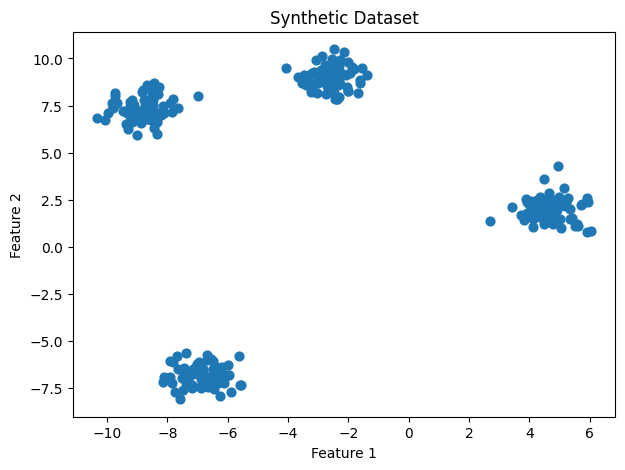

In [12]:
plt.figure(figsize=(7,5))
plt.scatter(X[:, 0], X[:, 1], s=40)
plt.title("Synthetic Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [13]:
kmeans = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit_predict(X)

In [15]:
# Calculate Silhouette Score

score = silhouette_score(X, labels)
print(f"Silhouette Score: {score:.4f}")

Silhouette Score: 0.8756


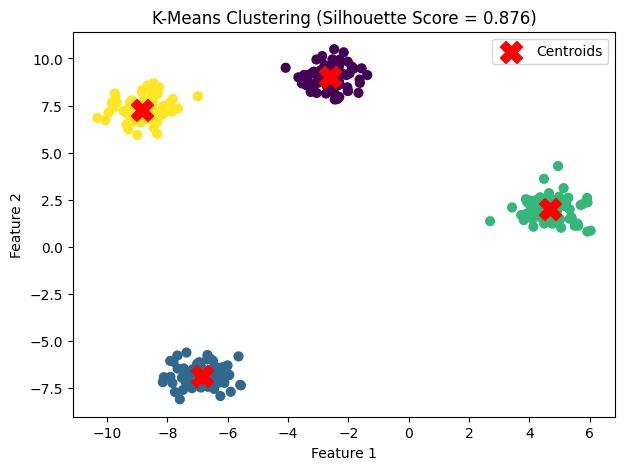

In [16]:
plt.figure(figsize=(7,5))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=labels,
    cmap="viridis",
    s=40
)

plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    c="red",
    marker="X",
    s=250,
    label="Centroids"
)

plt.title(f"K-Means Clustering (Silhouette Score = {score:.3f})")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

In [17]:
scores = []

for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=42)
    labels = model.fit_predict(X)

    score = silhouette_score(X, labels)
    scores.append(score)

    print(f"K = {k} --> Silhouette Score = {score:.4f}")

K = 2 --> Silhouette Score = 0.6155
K = 3 --> Silhouette Score = 0.7993
K = 4 --> Silhouette Score = 0.8756
K = 5 --> Silhouette Score = 0.7311
K = 6 --> Silhouette Score = 0.5853
K = 7 --> Silhouette Score = 0.4517
K = 8 --> Silhouette Score = 0.3296
K = 9 --> Silhouette Score = 0.3379
K = 10 --> Silhouette Score = 0.3592


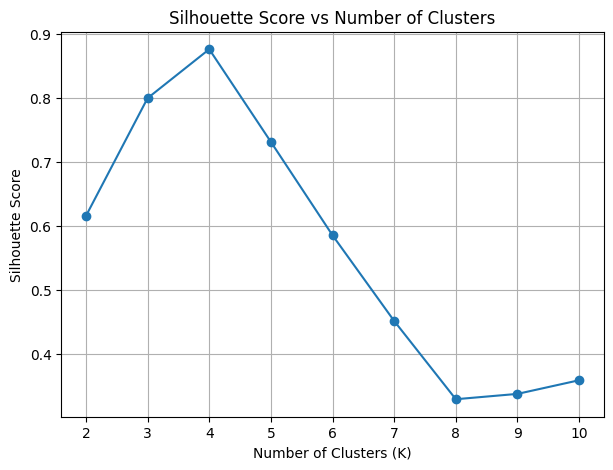

In [18]:
plt.figure(figsize=(7,5))

plt.plot(range(2, 11), scores, marker='o')

plt.title("Silhouette Score vs Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.grid(True)

plt.show()

## Conclusion

- The **highest Silhouette Score** indicates the **best number of clusters**.
- A score close to **1** means well-separated clusters.
- A score close to **0** means overlapping clusters.
- A **negative** score indicates that some points are likely assigned to the wrong cluster.